<a href="https://colab.research.google.com/github/aryanp2107/Reinforcement_learning/blob/main/RL_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import time
from IPython.display import clear_output

np.random.seed(42)

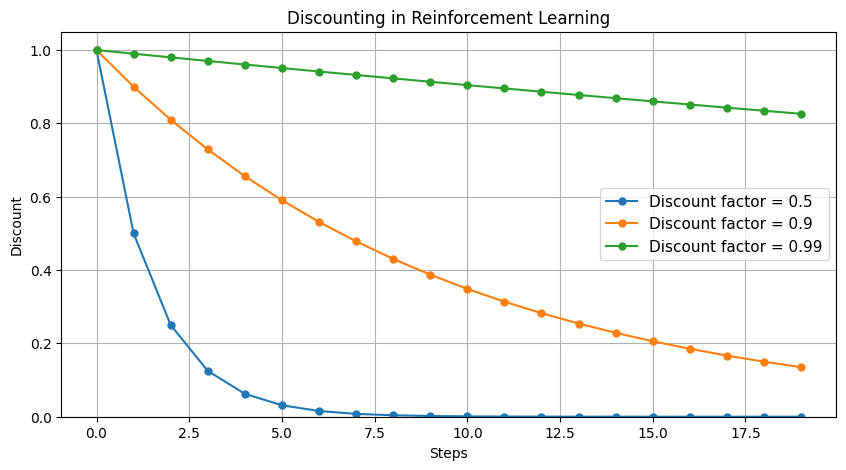

In [4]:
#visualizing discounting
gammas = [0.5, 0.9, 0.99]
steps = np.arange(20)

plt.figure(figsize=(10, 5))
for gamma in gammas:
  discount = gamma ** steps
  plt.plot(steps, discount, 'o-', label=f'Discount factor = {gamma}', markersize=5)

plt.xlabel('Steps')
plt.ylabel('Discount')
plt.legend()
plt.title('Discounting in Reinforcement Learning')
plt.legend(fontsize=11)
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

Gridworld environment

In [8]:
class GridWorld:
  """

  S  = start
  . = Empty (can walk)
  x = Wall (can't walk)
  G = goal (+10 reward)

  Actions: 0=up, 1=right, 2=down, 3=left
  Rewards: -0.1 perstep, +10 for goal, -1 for hitting the wall

  """

  def __init__(self):
    self.height = 4
    self.width = 4
    self.start = (0, 0)
    self.goal = (3, 3)
    self.walls = [(1, 1)]

    #action mapping
    self.actions = {
        0: (-1, 0),
        1: (1, 0),
        2: (0, -1),
        3: (0, 1)

    }

    self.action_names = ['UP', 'DOWN', 'LEFT', 'RIGHT']
    self.n_actions = 4

    self.reset()

  def reset(self):
    self.agent_pos = self.start
    return self.agent_pos

  def step(self, action):
    """
    take an action, return (next_state, reward, done)

    """

    #calculate new postion
    delta = self.actions[action]
    new_pos = (self.agent_pos[0] + delta[0],
               self.agent_pos[1] + delta[1])

    #checking boundaries
    if (new_pos[0] < 0 or new_pos[0] >= self.height or
        new_pos[1] < 0 or new_pos[1] >= self.width):
      #hit the boundary - stay in place, small penalty
      return self.agent_pos, -1.0, False

    #Checking the walls
    if new_pos in self.walls:
      #Hit wall - stay in place, small penalty
      return self.agent_pos, -1.0, False

    #A valid move
    self.agent_pos = new_pos

    #Checking if goal reached
    if self.agent_pos == self.goal:
      return self.agent_pos, 10.0, True

    #normal step
    return self.agent_pos, -0.1, False

  def render(self):
    grid = [['.' for _ in range(self.width)] for _ in range(self.height)]

    #mark walls
    for wall in self.walls:
      grid[wall[0]][wall[1]] = 'X'

    #Mark goal
    grid[self.goal[0]][self.goal[1]] = 'G'

    #mark agent
    grid[self.agent_pos[0]][self.agent_pos[1]] = 'A'

    print('\n'.join([' '.join(row) for row in grid]))
    print()


#testing the env
env = GridWorld()
print('Initial State: ')
env.render()

print("Take action DOWN: ")
state, reward, done = env.step(1)
print(f"New State: {state}, Reward: {reward}, Done: {done}")
env.render()


Initial State: 
A . . .
. X . .
. . . .
. . . G

Take action DOWN: 
New State: (1, 0), Reward: -0.1, Done: False
. . . .
A X . .
. . . .
. . . G



In [12]:
env.reset()

actions =  [1, 3, 1, 3, 1, 3, 3]

for a in actions:
  state, reward, done = env.step(a)
  print(f"Action: {env.action_names[a]:5s} -> State: {state}, Reward: {reward:+.1f}")
  if done:
    print("\nGoal Reached!!!")
    break

env.render()

Action: DOWN  -> State: (1, 0), Reward: -0.1
Action: RIGHT -> State: (1, 0), Reward: -1.0
Action: DOWN  -> State: (2, 0), Reward: -0.1
Action: RIGHT -> State: (2, 1), Reward: -0.1
Action: DOWN  -> State: (3, 1), Reward: -0.1
Action: RIGHT -> State: (3, 2), Reward: -0.1
Action: RIGHT -> State: (3, 3), Reward: +10.0

Goal Reached!!!
. . . .
. X . .
. . . .
. . . A



Q-Learning Agent

In [20]:
class QLearningAgent:
  """
  Tabular Q-Learning Agent

  """
  def __init__(self, n_actions, learning_rate=0.1, discount=0.99, epsilon=1.0):
    self.n_actions = n_actions
    self.lr = learning_rate
    self.discount = discount
    self.epsilon = epsilon
    self.q_table = defaultdict(float)

  def get_q_values(self, state):
    """ Getting Q values for all the actions in a state """
    return [self.q_table[(state, a)] for a in range(self.n_actions)]

  def choose_action(self, state):
    """ epsilon-greedy selection """

    if np.random.random() < self.epsilon:
      return np.random.randint(self.n_actions)  # explore
    else:
      q_values = self.get_q_values(state)      #exploit
      return np.argmax(q_values)

  def learn(self, state, action, reward, next_state, done):
    """ Q learning update"""

    current_q = self.q_table[(state, action)]

    #best q value for the next state
    if done:
      max_next_q = 0
    else:
      max_next_q = np.max(self.get_q_values(next_state))

    #TD target (what we think Q should be)
    td_target = reward + self.discount * max_next_q

    #TD error
    td_error = td_target - current_q

    #Update Q-Value
    self.q_table[(state, action)] = current_q + self.lr * td_error

  def decay_epsilon(self, decay_rate=0.995, min_epsilon=0.01):
    #Reduce the explotation over time
    self.epsilon = max(min_epsilon, self.epsilon * decay_rate)

print("Qlearning class defined")


Qlearning class defined


Training Loop

In [21]:
def train_agent(env, agent, n_episodes=500, max_steps=100, verbose=True):
  rewards_history = []
  steps_history = []

  for episode in range(n_episodes):
    state = env.reset()
    total_reward = 0
    steps = 0

    for step in range(max_steps):
      action = agent.choose_action(state)  # choose action
      next_state, reward, done = env.step(action)  # take action
      agent.learn(state, action, reward, next_state, done)  #learn

      state = next_state
      total_reward += reward
      steps += 1

      if done:
        break

    #decay exploration
    agent.decay_epsilon()

    rewards_history.append(total_reward)
    steps_history.append(steps)

    #progress
    if verbose and (episode + 1) % 100 == 0:
      avg_reward = np.mean(rewards_history[-100:])
      avg_steps = np.mean(steps_history[-100:])
      print(f"Episode: {episode+1:4d} | Avg Reward: {avg_reward:.2f} | Avg Steps: {avg_steps:.2f}")

  return rewards_history, steps_history

print("training Function defined")

training Function defined


In [22]:
#creating env and agent
env = GridWorld()
agent = QLearningAgent(
    n_actions=4,
    learning_rate=0.1,
    discount=0.99,
    epsilon=1.0
)

#training
rewards, steps = train_agent(env, agent, n_episodes=1000, verbose=True)

Episode:  100 | Avg Reward: -0.23 | Avg Steps: 27.25
Episode:  200 | Avg Reward: 7.20 | Avg Steps: 11.27
Episode:  300 | Avg Reward: 8.32 | Avg Steps: 9.07
Episode:  400 | Avg Reward: 8.93 | Avg Steps: 7.52
Episode:  500 | Avg Reward: 9.19 | Avg Steps: 6.81
Episode:  600 | Avg Reward: 9.24 | Avg Steps: 6.58
Episode:  700 | Avg Reward: 9.41 | Avg Steps: 6.23
Episode:  800 | Avg Reward: 9.45 | Avg Steps: 6.28
Episode:  900 | Avg Reward: 9.45 | Avg Steps: 6.10
Episode: 1000 | Avg Reward: 9.48 | Avg Steps: 6.11


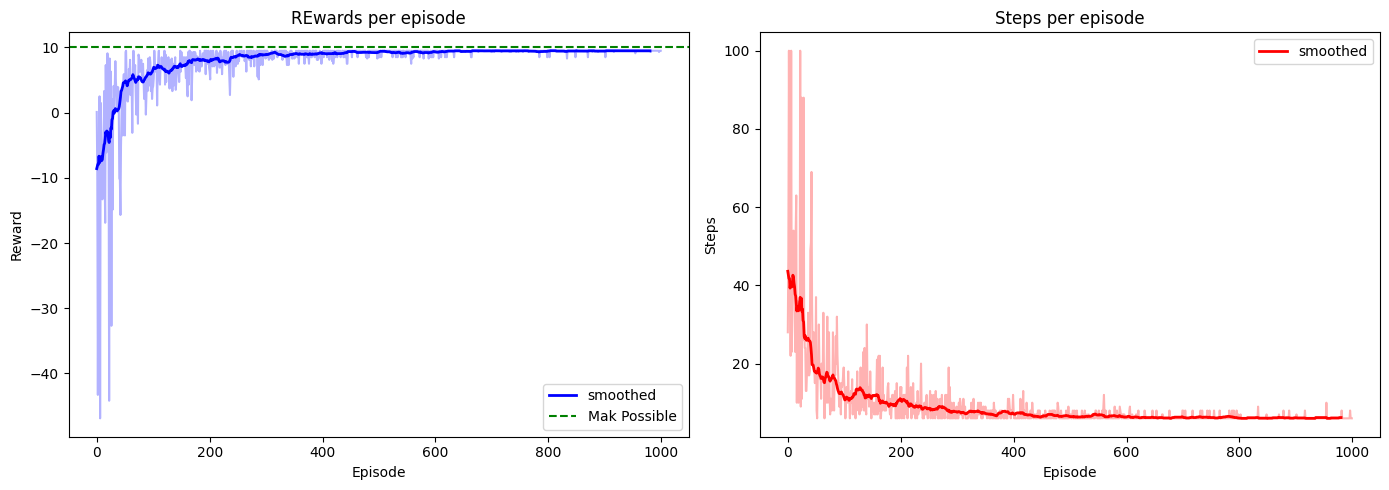

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def smooth(data, window=20):
  return np.convolve(data, np.ones(window)/window, mode='valid')

#rewards
axes[0].plot(rewards, alpha=0.3, color='blue')
axes[0].plot(smooth(rewards, 20), color='blue', linewidth=2, label='smoothed')
axes[0].axhline(y=10, color='green', linestyle='--', label='Mak Possible')
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Reward")
axes[0].set_title('REwards per episode')
axes[0].legend()

#Steps
axes[1].plot(steps, alpha=0.3, color='red')
axes[1].plot(smooth(steps, 20), color='red', linewidth=2, label='smoothed')
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Steps")
axes[1].set_title('Steps per episode')
axes[1].legend()

plt.tight_layout()
plt.show()

Visualizing the learned policy

In [27]:
def visualize_policy(agent, env):
  arrows = ['↑', '↓', '←', '→']

  print("Learned Policy:")
  for row in range(env.height):
    row_str = ""
    for col in range(env.width):
      state = (row, col)

      if state == env.goal:
        row_str += "G"

      elif state in env.walls:
        row_str += "X"

      else:
        q_values = agent.get_q_values(state)
        best_action = np.argmax(q_values)
        row_str += f"{arrows[best_action]}"

    print(row_str)

visualize_policy(agent, env)

Learned Policy:
→→→↓
↑X↓↓
→→→↓
→→→G


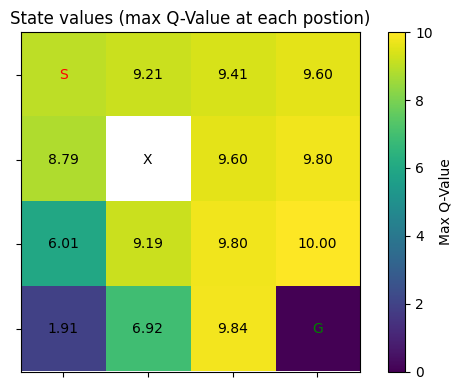

In [28]:
def visualize_q_values(agent, env):

  #get max Q-value for each state
  values = np.zeros((env.height, env.width))

  for row in range(env.height):
    for col in range(env.width):
      state = (row, col)
      if state in env.walls:
        values[row, col] = np.nan
      else:
        q_vals = agent.get_q_values(state)
        values[row, col] = max(q_vals)

  fig, ax = plt.subplots(figsize=(6, 4))

  im = ax.imshow(values, cmap='viridis', interpolation='nearest')
  plt.colorbar(im, label='Max Q-Value')

  for row in range(env.height):
    for col in range(env.width):
      state = (row, col)
      if state in env.walls:
        ax.text(col, row, 'X', ha='center', va='center', color='black')
      elif state == env.goal:
        ax.text(col, row, 'G', ha='center', va='center', color='green')
      elif state == env.start:
        ax.text(col, row, 'S', ha='center', va='center', color='red')
      else:
        ax.text(col, row, f"{values[row, col]:.2f}", ha='center', va='center')
  ax.set_title('State values (max Q-Value at each postion)')
  ax.set_xticks(range(env.width))
  ax.set_yticks(range(env.height))
  ax.set_xticklabels([])
  ax.set_yticklabels([])
  plt.tight_layout()
  plt.show()

visualize_q_values(agent, env)

In [30]:
def watch_agent(env, agent, max_steps=20):
    """Watch the trained agent solve the environment"""

    state = env.reset()
    total_reward = 0

    print("Watching trained agent...\n")
    print("Initial:")
    env.render()

    for step in range(max_steps):
        # Use greedy policy (no exploration)
        q_values = agent.get_q_values(state)
        action = np.argmax(q_values)

        next_state, reward, done = env.step(action)
        total_reward += reward

        print(f"Step {step+1}: {env.action_names[action]}")
        env.render()

        state = next_state

        if done:
            print(f"Goal reached in {step+1} steps!")
            print(f"Total reward: {total_reward:.1f}")
            return

    print(f"Did not reach goal in {max_steps} steps")

watch_agent(env, agent)

Watching trained agent...

Initial:
A . . .
. X . .
. . . .
. . . G

Step 1: RIGHT
. A . .
. X . .
. . . .
. . . G

Step 2: RIGHT
. . A .
. X . .
. . . .
. . . G

Step 3: RIGHT
. . . A
. X . .
. . . .
. . . G

Step 4: DOWN
. . . .
. X . A
. . . .
. . . G

Step 5: DOWN
. . . .
. X . .
. . . A
. . . G

Step 6: DOWN
. . . .
. X . .
. . . .
. . . A

Goal reached in 6 steps!
Total reward: 9.5


A Harder ENV

In [33]:
class HarderGridWorld(GridWorld):
  def __init__(self):
    super().__init__()
    self.height = 5
    self.width = 5
    self.goal = (4, 4)
    self.walls = [(1, 1), (1, 2), (2, 1), (3, 3), (2, 3)]

hard_env = HarderGridWorld()
print("Harder Environment:")
hard_env.render()

#Train a new agent
hard_agent = QLearningAgent(
    n_actions=4,
    learning_rate=0.1,
    discount=0.99,
    epsilon=1.0
)

print("Training the agent...")
hard_rewards, hard_steps = train_agent(hard_env, hard_agent, n_episodes=1000, verbose=True)

Harder Environment:
A . . . .
. X X . .
. X . X .
. . . X .
. . . . G

Training the agent...
Episode:  100 | Avg Reward: -7.20 | Avg Steps: 39.91
Episode:  200 | Avg Reward: 6.17 | Avg Steps: 14.75
Episode:  300 | Avg Reward: 7.98 | Avg Steps: 11.07
Episode:  400 | Avg Reward: 8.56 | Avg Steps: 9.68
Episode:  500 | Avg Reward: 8.81 | Avg Steps: 8.94
Episode:  600 | Avg Reward: 8.93 | Avg Steps: 8.59
Episode:  700 | Avg Reward: 9.21 | Avg Steps: 8.25
Episode:  800 | Avg Reward: 9.17 | Avg Steps: 8.27
Episode:  900 | Avg Reward: 9.25 | Avg Steps: 8.09
Episode: 1000 | Avg Reward: 9.27 | Avg Steps: 8.05


In [34]:
print("Learned Policy on the harder grid:")
visualize_policy(hard_agent, hard_env)
print("\n")
watch_agent(hard_env, hard_agent)

Learned Policy on the harder grid:
Learned Policy:
↓←←→↓
↓XX→↓
↓X↓X↓
→↓↓X↓
→→→→G


Watching trained agent...

Initial:
A . . . .
. X X . .
. X . X .
. . . X .
. . . . G

Step 1: DOWN
. . . . .
A X X . .
. X . X .
. . . X .
. . . . G

Step 2: DOWN
. . . . .
. X X . .
A X . X .
. . . X .
. . . . G

Step 3: DOWN
. . . . .
. X X . .
. X . X .
A . . X .
. . . . G

Step 4: RIGHT
. . . . .
. X X . .
. X . X .
. A . X .
. . . . G

Step 5: DOWN
. . . . .
. X X . .
. X . X .
. . . X .
. A . . G

Step 6: RIGHT
. . . . .
. X X . .
. X . X .
. . . X .
. . A . G

Step 7: RIGHT
. . . . .
. X X . .
. X . X .
. . . X .
. . . A G

Step 8: RIGHT
. . . . .
. X X . .
. X . X .
. . . X .
. . . . A

Goal reached in 8 steps!
Total reward: 9.3


In [35]:
# Save the Q-table for reference
print("Sample Q-values from trained agent:\n")
for state in [(0,0), (0,1), (1,0), (2,2), (2,3)]:
    q_vals = agent.get_q_values(state)
    best = np.argmax(q_vals)
    print(f"State {state}:")
    for i, (name, q) in enumerate(zip(env.action_names, q_vals)):
        marker = " ← BEST" if i == best else ""
        print(f"    {name:5s}: {q:+6.2f}{marker}")
    print()

Sample Q-values from trained agent:

State (0, 0):
    UP   :  +7.79
    DOWN :  +8.43
    LEFT :  +7.92
    RIGHT:  +9.02 ← BEST

State (0, 1):
    UP   :  +8.09
    DOWN :  +8.08
    LEFT :  +8.81
    RIGHT:  +9.21 ← BEST

State (1, 0):
    UP   :  +8.79 ← BEST
    DOWN :  +3.05
    LEFT :  +2.59
    RIGHT:  +2.57

State (2, 2):
    UP   :  +8.09
    DOWN :  +9.27
    LEFT :  +7.56
    RIGHT:  +9.80 ← BEST

State (2, 3):
    UP   :  +9.59
    DOWN : +10.00 ← BEST
    LEFT :  +9.59
    RIGHT:  +8.89

